# Model Init - Per-Year Baseline (Spark ML Regression)

## Objective
Build a baseline train/test workflow on `data/features_temp/community_features/model_features_all` using all rows, with an 80/20 split evaluated separately by `ride_year`.

## Plan
1. Start Spark in local mode and load the full feature table.
2. Build per-year chronological 80/20 train/test splits.
3. Train the simplest fast Spark ML regression baseline (Linear Regression).
4. Evaluate each year overall and by `canonical_station_id` MAE.
5. Plot test-set actual vs prediction per year and report combined top-10 coefficient magnitudes.

In [26]:
from pathlib import Path
from typing import Tuple, Dict

import numpy as np
import pandas as pd

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("bixi-model-init-community-baseline")
    .master("local[*]")
    .getOrCreate()
)

spark.conf.set("spark.sql.session.timeZone", "America/Toronto")
print("Spark version:", spark.version)
print("Spark master:", spark.sparkContext.master)

Spark version: 4.0.1
Spark master: local[*]


26/03/26 21:40:15 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


In [27]:
# Task 1: load full model feature table (no community filter).
features_path = Path("data/features_temp/community_features/model_features_all")
if not features_path.exists():
    raise FileNotFoundError(f"Missing features path: {features_path}")

features_sdf = spark.read.parquet(str(features_path))
print("Loaded path:", features_path)
print("Total rows:", f"{features_sdf.count():,}")
print("Columns:", len(features_sdf.columns))

required_cols = {"ride_year", "ts_hour", "canonical_station_id", "station_outflow"}
missing_required = sorted(required_cols - set(features_sdf.columns))
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

year_profile = features_sdf.groupBy("ride_year").count().orderBy("ride_year")
print("Rows by ride_year:")
year_profile.show(truncate=False)

features_sdf.printSchema()
display(features_sdf.limit(20).toPandas())

Loaded path: data/features_temp/community_features/model_features_all
Total rows: 7,460,963
Columns: 60
Rows by ride_year:
+---------+-------+
|ride_year|count  |
+---------+-------+
|2024     |3561532|
|2025     |3842550|
|2026     |56881  |
+---------+-------+

root
 |-- community: long (nullable = true)
 |-- ts_hour: timestamp (nullable = true)
 |-- canonical_station_id: string (nullable = true)
 |-- station_inflow: long (nullable = true)
 |-- station_outflow: long (nullable = true)
 |-- station_net_flow: long (nullable = true)
 |-- community_active_stations: long (nullable = true)
 |-- community_inflow: long (nullable = true)
 |-- community_outflow: long (nullable = true)
 |-- community_net_flow: long (nullable = true)
 |-- hour: integer (nullable = true)
 |-- dow: integer (nullable = true)
 |-- is_weekend: integer (nullable = true)
 |-- hour_sin: double (nullable = true)
 |-- hour_cos: double (nullable = true)
 |-- dow_sin: double (nullable = true)
 |-- dow_cos: double (nullable =

,community,ts_hour,canonical_station_id,station_inflow,station_outflow,station_net_flow,community_active_stations,community_inflow,community_outflow,community_net_flow,...,community_inflow_lag_48,community_outflow_lag_48,community_net_flow_lag_48,station_inflow_lag_168,station_outflow_lag_168,station_net_flow_lag_168,community_inflow_lag_168,community_outflow_lag_168,community_net_flow_lag_168,ride_year
0,0,2024-01-01 00:00:00,STN_0080,0,3,-3,11,10,14,-4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024
1,0,2024-09-22 01:00:00,STN_0531,2,0,2,132,291,314,-23,...,291.0,314.0,-23.0,2.0,1.0,1.0,408.0,407.0,1.0,2024
2,0,2024-01-01 00:00:00,STN_0179,2,2,0,11,10,14,-4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024
3,0,2024-09-22 01:00:00,STN_0798,2,1,1,132,291,314,-23,...,291.0,314.0,-23.0,1.0,1.0,0.0,408.0,407.0,1.0,2024
4,0,2024-01-01 00:00:00,STN_0126,0,1,-1,11,10,14,-4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024
5,0,2024-09-22 01:00:00,STN_0081,3,1,2,132,291,314,-23,...,291.0,314.0,-23.0,6.0,8.0,-2.0,408.0,407.0,1.0,2024
6,0,2024-01-01 00:00:00,STN_0172,1,3,-2,11,10,14,-4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024
7,0,2024-09-22 01:00:00,STN_0671,1,2,-1,132,291,314,-23,...,291.0,314.0,-23.0,3.0,0.0,3.0,408.0,407.0,1.0,2024
8,0,2024-01-01 00:00:00,STN_0573,3,0,3,11,10,14,-4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024
9,0,2024-09-22 01:00:00,STN_0002,7,8,-1,132,291,314,-23,...,291.0,314.0,-23.0,33.0,36.0,-3.0,408.0,407.0,1.0,2024


In [28]:
# Task 2: prepare model table, feature-selection config, and per-year 80/20 split metadata.
target_col = "station_outflow"

# Exclude these years from both training and testing.
excluded_ride_years = [2026]

# Keep these columns available as model features (as requested).
forced_feature_cols = ["canonical_station_id", "community", "ride_year", "ts_hour"]

# Feature-selection controls (edit these to run ablations quickly).
feature_selection_mode = "all"  # options: all, calendar_only, lags_only, no_community
feature_drop_cols = []  # explicit removals after mode selection
feature_add_cols = []   # explicit additions after mode selection

# Exclude direct target leakage columns while keeping broad candidate signals.
excluded_cols = {
    target_col,
    "station_inflow",
    "station_net_flow",
    "community_inflow",
    "community_outflow",
    "community_net_flow",
}

candidate_feature_cols = [
    c for c in features_sdf.columns
    if c not in excluded_cols
]

calendar_cols = [
    c for c in ["hour", "dow", "is_weekend", "hour_sin", "hour_cos", "dow_sin", "dow_cos"]
    if c in candidate_feature_cols
]
lag_roll_cols = [
    c for c in candidate_feature_cols
    if ("_lag_" in c) or ("_roll_" in c)
]
community_feature_cols = [
    c for c in candidate_feature_cols
    if c.startswith("community_") and c not in {"community"}
]

if feature_selection_mode == "all":
    selected = set(candidate_feature_cols)
elif feature_selection_mode == "calendar_only":
    selected = set(calendar_cols) | set(forced_feature_cols)
elif feature_selection_mode == "lags_only":
    selected = set(lag_roll_cols) | set(forced_feature_cols)
elif feature_selection_mode == "no_community":
    selected = {
        c for c in candidate_feature_cols
        if not c.startswith("community_") or c == "community"
    }
else:
    raise ValueError(f"Unsupported feature_selection_mode: {feature_selection_mode}")

selected |= set(feature_add_cols)
selected -= set(feature_drop_cols)
selected |= set(forced_feature_cols)

feature_cols = [c for c in candidate_feature_cols if c in selected]

# Ensure forced columns are present and included.
missing_forced = [c for c in forced_feature_cols if c not in feature_cols]
if missing_forced:
    raise ValueError(f"Missing required forced feature columns: {missing_forced}")

model_sdf = (
    features_sdf
    .select(*feature_cols, target_col)
    .where(F.col("ride_year").isNotNull())
    .where(~F.col("ride_year").isin([int(y) for y in excluded_ride_years]))
    .where(F.col("ts_hour").isNotNull())
    .where(F.col("canonical_station_id").isNotNull())
    .where(F.col("community").isNotNull())
    .where(F.col(target_col).isNotNull())
    .dropna(subset=feature_cols)
)

year_values = [int(r["ride_year"]) for r in model_sdf.select("ride_year").distinct().orderBy("ride_year").collect()]
if not year_values:
    raise ValueError("No ride_year values found after filtering")

year_split_meta = {}
for y in year_values:
    y_sdf = model_sdf.where(F.col("ride_year") == F.lit(y))

    ts_year_pd = y_sdf.select("ts_hour").distinct().orderBy("ts_hour").toPandas()
    ts_year_pd["ts_hour"] = pd.to_datetime(ts_year_pd["ts_hour"])
    if len(ts_year_pd) < 25:
        print(f"Skipping year {y}: not enough unique hours ({len(ts_year_pd)})")
        continue

    split_idx = max(1, int(len(ts_year_pd) * 0.8))
    if split_idx >= len(ts_year_pd):
        split_idx = len(ts_year_pd) - 1
    split_ts = ts_year_pd.iloc[split_idx]["ts_hour"]

    train_rows = y_sdf.where(F.col("ts_hour") < F.lit(split_ts)).count()
    test_rows = y_sdf.where(F.col("ts_hour") >= F.lit(split_ts)).count()

    if train_rows == 0 or test_rows == 0:
        print(f"Skipping year {y}: empty split train={train_rows}, test={test_rows}")
        continue

    year_split_meta[y] = {
        "split_ts": split_ts,
        "n_hours": len(ts_year_pd),
        "train_rows": int(train_rows),
        "test_rows": int(test_rows),
    }

if not year_split_meta:
    raise ValueError("No valid per-year 80/20 splits were created")

split_summary = pd.DataFrame([
    {
        "ride_year": y,
        "n_hours": d["n_hours"],
        "split_ts": d["split_ts"],
        "train_rows": d["train_rows"],
        "test_rows": d["test_rows"],
    }
    for y, d in year_split_meta.items()
]).sort_values("ride_year").reset_index(drop=True)

print("Target:", target_col)
print("Excluded ride_years:", excluded_ride_years)
print("Feature mode:", feature_selection_mode)
print("Feature count:", len(feature_cols))
print("Per-year chronological split ratio: 80/20")
display(split_summary)
display(pd.DataFrame({"feature_cols": feature_cols}).head(40))

Target: station_outflow
Excluded ride_years: [2026]
Feature mode: all
Feature count: 54
Per-year chronological split ratio: 80/20


,ride_year,n_hours,split_ts,train_rows,test_rows
0,2024,8571,2024-10-21 11:00:00,2854279,539356
1,2025,8571,2025-10-21 12:00:00,3115728,534039


,feature_cols
0,community
1,ts_hour
2,canonical_station_id
3,community_active_stations
4,hour
5,dow
6,is_weekend
7,hour_sin
8,hour_cos
9,dow_sin


In [29]:
# Task 3: Spark ML regression utilities (no NumPy ridge).
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import LinearRegression


def build_year_model_inputs(df):
    return (
        df
        .withColumn("ride_year_num", F.col("ride_year").cast("double"))
        .withColumn("community_num", F.col("community").cast("double"))
        .withColumn("ts_hour_num", F.col("ts_hour").cast("long").cast("double"))
    )


def build_pipeline(assembler_input_cols):
    station_indexer = StringIndexer(
        inputCol="canonical_station_id",
        outputCol="canonical_station_id_idx",
        handleInvalid="keep",
    )
    assembler = VectorAssembler(
        inputCols=assembler_input_cols,
        outputCol="features",
        handleInvalid="skip",
    )
    lr = LinearRegression(
        featuresCol="features",
        labelCol=target_col,
        predictionCol="prediction",
        maxIter=20,
        regParam=0.0,
        elasticNetParam=0.0,
        solver="normal",
    )
    return Pipeline(stages=[station_indexer, assembler, lr])


# Build assembler feature list from requested feature columns.
base_numeric_feature_cols = [
    c for c in feature_cols
    if c not in {"canonical_station_id", "community", "ride_year", "ts_hour"}
]
assembler_input_cols = [
    "canonical_station_id_idx",
    "community_num",
    "ride_year_num",
    "ts_hour_num",
    *base_numeric_feature_cols,
]

print("Spark ML utilities ready.")
print("Assembler feature count:", len(assembler_input_cols))

Spark ML utilities ready.
Assembler feature count: 54


26/03/26 21:44:18 WARN Instrumentation: [14fe6f6d] regParam is zero, which might cause numerical instability and overfitting.
26/03/26 21:44:36 WARN Instrumentation: [14fe6f6d] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/03/26 21:46:51 WARN Instrumentation: [e0cd1f66] regParam is zero, which might cause numerical instability and overfitting.
26/03/26 21:47:08 WARN Instrumentation: [e0cd1f66] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


Per-year baseline metrics:


,ride_year,model,target,n_train,n_test,n_features,mae,rmse,r2,test_mean_target
0,2024,spark_linear_regression,station_outflow,2854279,539356,54,1.568506,2.348480,0.577481,2.847717
1,2025,spark_linear_regression,station_outflow,3115728,534039,54,1.431483,2.177483,0.572965,2.481519


Combined top-10 coefficient magnitudes:


,feature,mean_abs_coef,max_abs_coef,n_years
0,hour_cos,0.361249,0.364842,2
1,station_outflow_lag_1,0.236307,0.239610,2
2,station_inflow_lag_1,0.221870,0.225028,2
3,station_outflow_lag_2,0.070650,0.070698,2
4,station_inflow_lag_2,0.069352,0.069730,2
5,dow_sin,0.061078,0.071900,2
6,is_weekend,0.052711,0.071298,2
7,station_outflow_lag_24,0.050699,0.051816,2
8,hour_sin,0.046012,0.054997,2
9,station_inflow_lag_24,0.039192,0.039284,2


Per-station MAE - ride_year=2024:


,ride_year,canonical_station_id,mae,n_rows
0,2024,STN_0001,3.309152,1582
1,2024,STN_0002,4.144583,1541
2,2024,STN_0003,3.456496,839
3,2024,STN_0004,3.593593,1486
4,2024,STN_0005,3.026372,1549
...,...,...,...,...
877,2024,STN_1288,0.664544,2
878,2024,STN_1298,1.024049,2
879,2024,STN_1304,1.500351,22
880,2024,STN_1311,1.612327,7


Per-station MAE - ride_year=2025:


,ride_year,canonical_station_id,mae,n_rows
0,2025,STN_0001,6.046669,497
1,2025,STN_0002,3.957790,1502
2,2025,STN_0003,2.368051,752
3,2025,STN_0004,3.271421,1481
4,2025,STN_0005,2.509142,1456
...,...,...,...,...
996,2025,STN_1317,1.106666,11
997,2025,STN_1320,0.580863,54
998,2025,STN_1328,0.778842,6
999,2025,STN_1336,0.877919,31


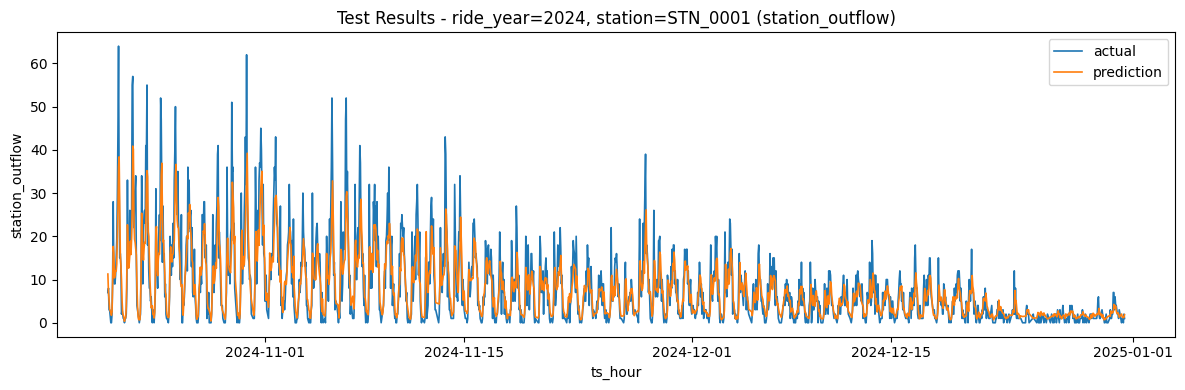

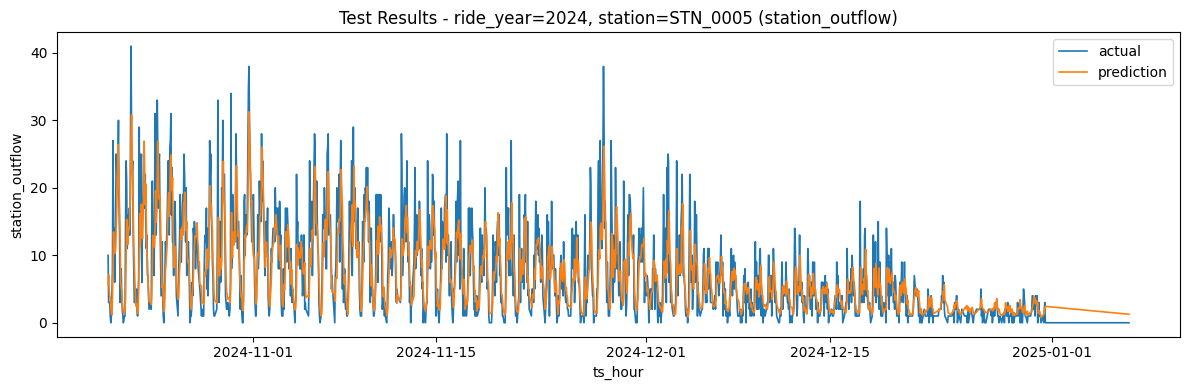

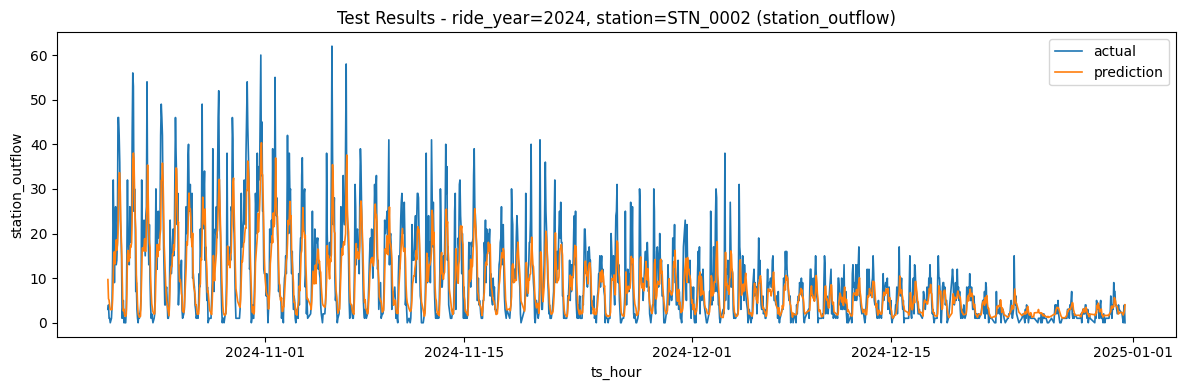

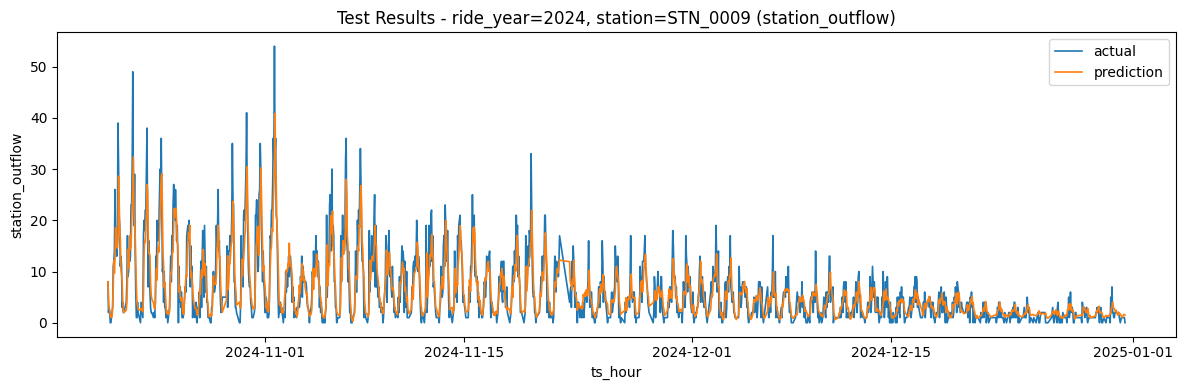

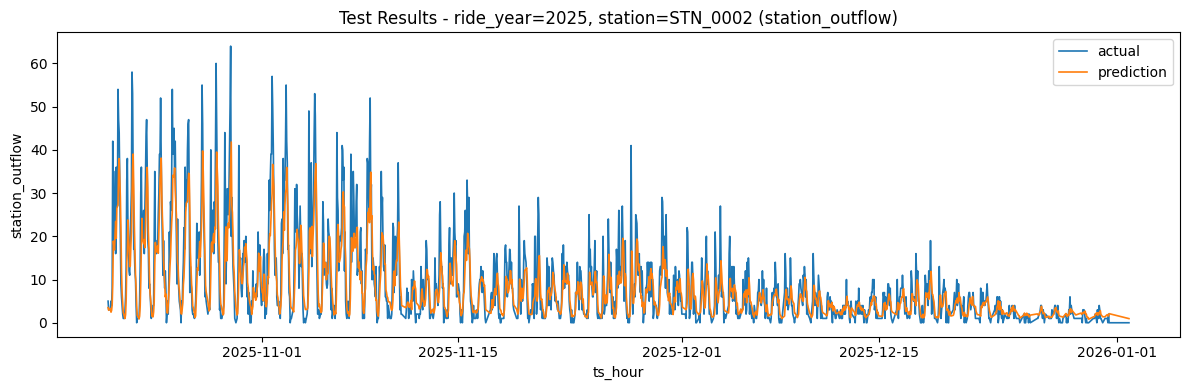

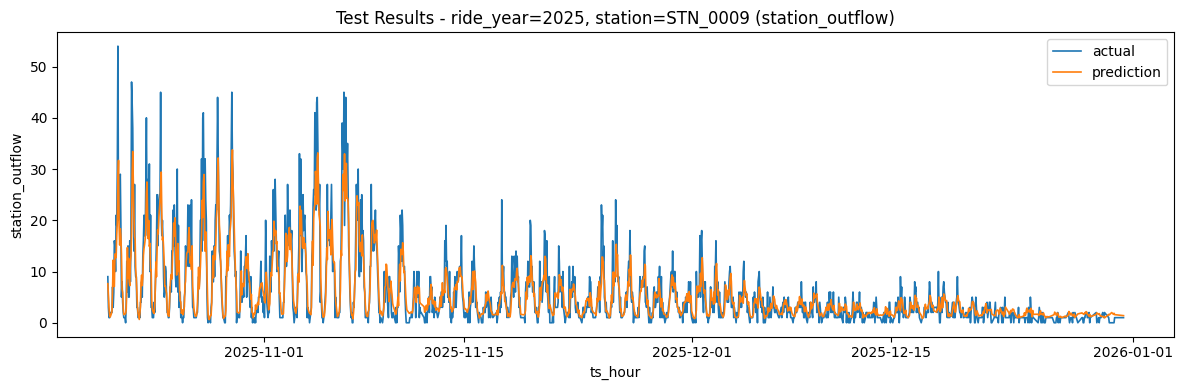

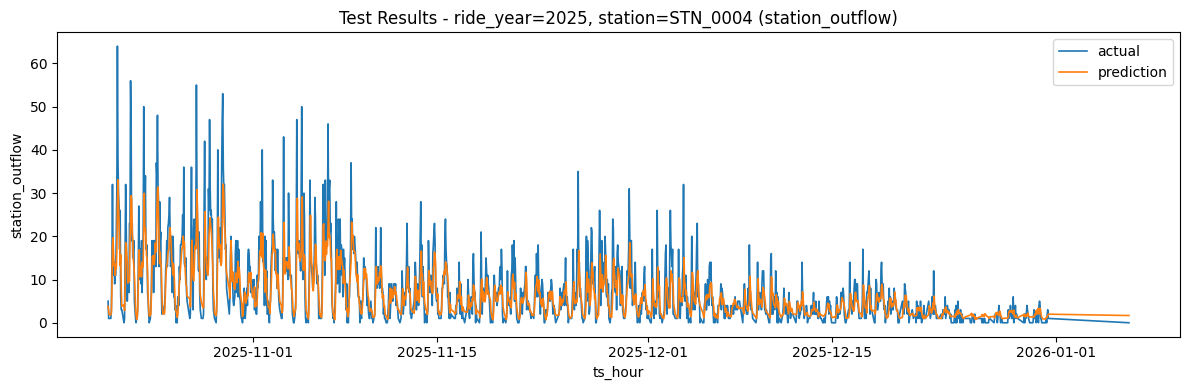

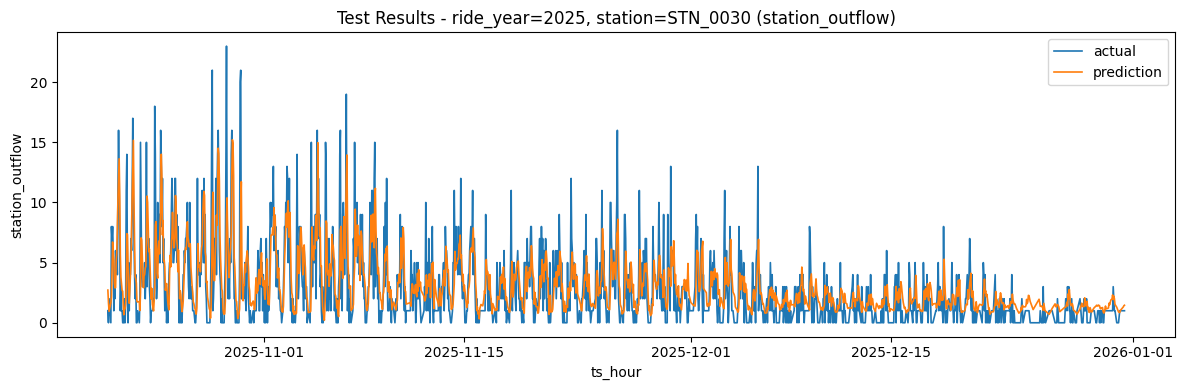

In [30]:
# Task 4: train/evaluate Spark ML linear regression for each year and plot station-level test results.
import matplotlib.pyplot as plt

metrics_rows = []
station_mae_tables = {}
coef_tables = []
station_plot_tables = {}
top_k_stations_for_plots = 4

for y in sorted(year_split_meta.keys()):
    split_ts = year_split_meta[y]["split_ts"]

    y_sdf = model_sdf.where(F.col("ride_year") == F.lit(y))
    train_sdf_y = y_sdf.where(F.col("ts_hour") < F.lit(split_ts))
    test_sdf_y = y_sdf.where(F.col("ts_hour") >= F.lit(split_ts))

    train_in = build_year_model_inputs(train_sdf_y)
    test_in = build_year_model_inputs(test_sdf_y)

    pipeline = build_pipeline(assembler_input_cols)
    fitted = pipeline.fit(train_in)
    pred_sdf = fitted.transform(test_in).select(
        "ride_year", "ts_hour", "canonical_station_id", target_col, "prediction"
    )

    # Overall metrics for the year.
    err_sdf = pred_sdf.withColumn("abs_err", F.abs(F.col(target_col) - F.col("prediction")))
    yearly_metrics = err_sdf.select(
        F.avg("abs_err").alias("mae"),
        F.sqrt(F.avg(F.pow(F.col(target_col) - F.col("prediction"), 2))).alias("rmse"),
        F.avg(F.col(target_col)).alias("test_mean_target"),
        F.count("*").alias("n_test_used"),
    ).first()

    y_mean = yearly_metrics["test_mean_target"]
    ss_res = err_sdf.select(F.sum(F.pow(F.col(target_col) - F.col("prediction"), 2)).alias("ss_res")).first()["ss_res"]
    ss_tot = pred_sdf.select(F.sum(F.pow(F.col(target_col) - F.lit(y_mean), 2)).alias("ss_tot")).first()["ss_tot"]
    r2 = float(1 - ss_res / ss_tot) if ss_tot and ss_tot > 0 else np.nan

    metrics_rows.append({
        "ride_year": y,
        "model": "spark_linear_regression",
        "target": target_col,
        "n_train": int(year_split_meta[y]["train_rows"]),
        "n_test": int(year_split_meta[y]["test_rows"]),
        "n_features": len(assembler_input_cols),
        "mae": float(yearly_metrics["mae"]),
        "rmse": float(yearly_metrics["rmse"]),
        "r2": r2,
        "test_mean_target": float(yearly_metrics["test_mean_target"]),
    })

    # Per-station MAE for this test split.
    station_mae_sdf = (
        err_sdf
        .groupBy("canonical_station_id")
        .agg(
            F.avg("abs_err").alias("mae"),
            F.count("*").alias("n_rows"),
        )
        .orderBy("canonical_station_id")
    )
    station_mae_pd = station_mae_sdf.toPandas()
    station_mae_pd.insert(0, "ride_year", y)
    station_mae_tables[y] = station_mae_pd

    # Choose top stations by test row count for visualization.
    top_station_ids = [
        r["canonical_station_id"]
        for r in station_mae_sdf.orderBy(F.desc("n_rows"), F.asc("canonical_station_id")).limit(top_k_stations_for_plots).collect()
    ]

    station_plot_tables[y] = {}
    for station_id in top_station_ids:
        station_pd = (
            pred_sdf
            .where(F.col("canonical_station_id") == F.lit(station_id))
            .orderBy("ts_hour")
            .toPandas()
        )
        station_pd["ts_hour"] = pd.to_datetime(station_pd["ts_hour"])
        station_plot_tables[y][station_id] = station_pd

    # Coefficients per year for later combined top-10 by magnitude.
    lr_model = fitted.stages[-1]
    coef_df_y = pd.DataFrame({
        "ride_year": y,
        "feature": assembler_input_cols,
        "coef": lr_model.coefficients.toArray(),
    })
    coef_df_y["abs_coef"] = coef_df_y["coef"].abs()
    coef_tables.append(coef_df_y)

metrics_df = pd.DataFrame(metrics_rows).sort_values("ride_year").reset_index(drop=True)
print("Per-year baseline metrics:")
display(metrics_df)

# Combined top-10 coefficient magnitudes across years.
coef_all_df = pd.concat(coef_tables, ignore_index=True)
coef_summary_df = (
    coef_all_df.groupby("feature", as_index=False)
    .agg(
        mean_abs_coef=("abs_coef", "mean"),
        max_abs_coef=("abs_coef", "max"),
        n_years=("ride_year", "nunique"),
    )
    .sort_values("mean_abs_coef", ascending=False)
    .reset_index(drop=True)
)
print("Combined top-10 coefficient magnitudes:")
display(coef_summary_df.head(10))

for y in sorted(station_mae_tables.keys()):
    print(f"Per-station MAE - ride_year={y}:")
    display(station_mae_tables[y])

for y in sorted(station_plot_tables.keys()):
    for station_id, station_df in station_plot_tables[y].items():
        plt.figure(figsize=(12, 4))
        plt.plot(station_df["ts_hour"], station_df[target_col], label="actual", linewidth=1.2)
        plt.plot(station_df["ts_hour"], station_df["prediction"], label="prediction", linewidth=1.2)
        plt.title(f"Test Results - ride_year={y}, station={station_id} ({target_col})")
        plt.xlabel("ts_hour")
        plt.ylabel(target_col)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [24]:
spark.stop()